In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("raw_metadata.csv")

# Display first 5 rows
df.head()

,video_id,title,publish_date
0,wppNtDrquVc,Learn English with Disney&#39;s UP — The Adven...,2026-03-04T14:01:22Z
1,2sgxlayFzko,Learn ENGLISH with Dragon Ball Daima,2026-02-28T14:00:08Z
2,1fn8R_PNAY0,Learn English with BAD BUNNY — Intermediate Le...,2026-02-25T13:30:04Z
3,CKTPXv9XCeA,Learn English with MODERN FAMILY — With Gloria...,2026-02-21T13:30:11Z
4,ULwzy4Y2qk8,Learn English with DESPICABLE ME,2026-02-18T15:02:50Z


In [3]:
# Print dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (398, 3)


Step2

In [4]:
# Column names
print("Columns:", df.columns.tolist())

# Data types
print("\nData Types:\n", df.dtypes)

# Total rows
print("\nTotal Rows:", len(df))

Columns: ['video_id', 'title', 'publish_date']

Data Types:
 video_id        object
title           object
publish_date    object
dtype: object

Total Rows: 398


In [5]:
# Confirm required columns exist
required_columns = ["video_id", "title", "publish_date"]

for col in required_columns:
    print(f"{col} exists:", col in df.columns)

video_id exists: True
title exists: True
publish_date exists: True


Step3

In [6]:
# Duplicate video_id
duplicate_ids = df["video_id"].duplicated().sum()
print("Duplicate video IDs:", duplicate_ids)

# Duplicate titles
duplicate_titles = df["title"].duplicated().sum()
print("Duplicate titles:", duplicate_titles)

Duplicate video IDs: 0
Duplicate titles: 1


In [7]:
# Remove duplicate video_id entries
df = df.drop_duplicates(subset="video_id")

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (398, 3)


Step4

In [8]:
print("Null Values:\n", df.isnull().sum())

Null Values:
 video_id        0
title           0
publish_date    0
dtype: int64


In [9]:
# Remove rows with missing critical values
df = df.dropna(subset=["video_id", "title", "publish_date"])

print("Shape after removing nulls:", df.shape)

Shape after removing nulls: (398, 3)


Step5

In [10]:
df["publish_date"] = pd.to_datetime(df["publish_date"])

# Extract year and month
df["year"] = df["publish_date"].dt.year
df["month"] = df["publish_date"].dt.month

df.head()

,video_id,title,publish_date,year,month
0,wppNtDrquVc,Learn English with Disney&#39;s UP — The Adven...,2026-03-04 14:01:22+00:00,2026,3
1,2sgxlayFzko,Learn ENGLISH with Dragon Ball Daima,2026-02-28 14:00:08+00:00,2026,2
2,1fn8R_PNAY0,Learn English with BAD BUNNY — Intermediate Le...,2026-02-25 13:30:04+00:00,2026,2
3,CKTPXv9XCeA,Learn English with MODERN FAMILY — With Gloria...,2026-02-21 13:30:11+00:00,2026,2
4,ULwzy4Y2qk8,Learn English with DESPICABLE ME,2026-02-18 15:02:50+00:00,2026,2


Step6

In [11]:
videos_per_year = df["year"].value_counts().sort_index()
videos_per_year

,count
year,
2017,1
2018,4
2019,18
2020,61
2021,56
2022,57
2023,54
2024,49
2025,81


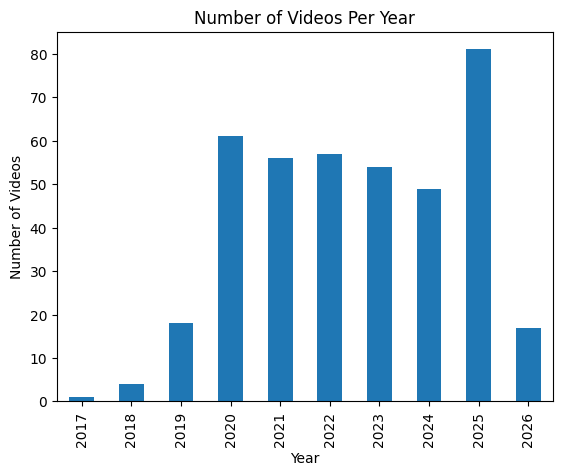

In [12]:
import matplotlib.pyplot as plt

plt.figure()
videos_per_year.plot(kind="bar")
plt.title("Number of Videos Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Videos")
plt.show()

In [13]:
videos_per_month = df["month"].value_counts().sort_index()
videos_per_month

,count
month,
1,35
2,41
3,33
4,24
5,35
6,36
7,37
8,33
9,23


Step7

In [14]:
# Title length
df["title_length"] = df["title"].str.len()

print("Shortest title length:", df["title_length"].min())
print("Longest title length:", df["title_length"].max())
print("Average title length:", df["title_length"].mean())

Shortest title length: 21
Longest title length: 105
Average title length: 50.414572864321606


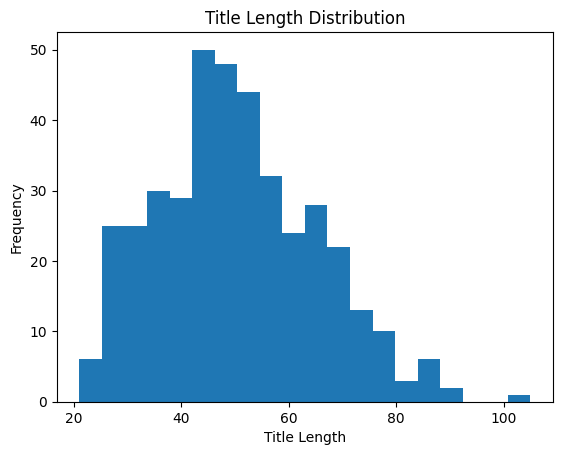

In [15]:
# Plot title length distribution
plt.figure()
df["title_length"].plot(kind="hist", bins=20)
plt.title("Title Length Distribution")
plt.xlabel("Title Length")
plt.ylabel("Frequency")
plt.show()

Step8

In [16]:
print("Total Unique Videos:", df["video_id"].nunique())

print("Date Range:")
print("From:", df["publish_date"].min())
print("To:", df["publish_date"].max())

Total Unique Videos: 398
Date Range:
From: 2017-10-12 13:59:48+00:00
To: 2026-03-04 14:01:22+00:00


Step9

In [17]:
df["title"] = df["title"].str.strip()  # remove extra spaces
df["title"] = df["title"].str.replace("\n", " ", regex=True)

df.head()

,video_id,title,publish_date,year,month,title_length
0,wppNtDrquVc,Learn English with Disney&#39;s UP — The Adven...,2026-03-04 14:01:22+00:00,2026,3,63
1,2sgxlayFzko,Learn ENGLISH with Dragon Ball Daima,2026-02-28 14:00:08+00:00,2026,2,36
2,1fn8R_PNAY0,Learn English with BAD BUNNY — Intermediate Le...,2026-02-25 13:30:04+00:00,2026,2,50
3,CKTPXv9XCeA,Learn English with MODERN FAMILY — With Gloria...,2026-02-21 13:30:11+00:00,2026,2,63
4,ULwzy4Y2qk8,Learn English with DESPICABLE ME,2026-02-18 15:02:50+00:00,2026,2,32


Step10

In [18]:
df.to_csv("cleaned_metadata.csv", index=False)

print("cleaned_metadata.csv saved successfully.")

cleaned_metadata.csv saved successfully.
